# **AI-Based Brain Tumor Detection Using MobileNetV2**

## **`Install Required Libraries`**

In [1]:
!pip install tensorflow opencv-python-headless matplotlib scikit-learn tqdm pandas gradio fpdf2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 17.6 MB/s eta 0:00:00


In [2]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 6.0 MB/s eta 0:00:00


In [3]:
!pip install -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 760.6/760.6 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.7/240.7 kB 20.4 MB/s eta 0:00:00
  Attempting uninstall: google-auth
    Found existing installation: google-auth 2.47.0
    Uninstalling google-auth-2.47.0:
      Successfully uninstalled google-auth-2.47.0
  Attempting uninstall: google-genai
    Found existing installation: google-genai 1.68.0
    Uninstalling google-genai-1.68.0:
      Successfully uninstalled google-genai-1.68.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.49.1 which is incompatible.


# **`Imports`**

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import datetime
from groq import Groq
from google.colab import userdata

client_groq = Groq(api_key=userdata.get("GROQ_API_KEY"))


from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.utils import Sequence

import gradio as gr
from fpdf import FPDF



In [2]:
from google.colab import files
import zipfile

# `Upload & Unzip Dataset`

In [6]:
# Upload dataset zip file (Choose Files)
uploaded = files.upload()

for fn in uploaded.keys():
    print('Uploaded file:', fn)
    with zipfile.ZipFile(fn, 'r') as zip_ref:
        zip_ref.extractall('/content/dataset')

print("Dataset uploaded and unzipped successfully!")

Saving MRI Dataset.zip to MRI Dataset.zip
Uploaded file: MRI Dataset.zip
Dataset uploaded and unzipped successfully!


# `Load Images & Labels`

In [3]:
# Automatically detect dataset root after unzipping
dataset_root = os.path.join('/content/dataset', 'train') # Changed from test to train
print("Dataset root detected:", dataset_root)

categories = ['glioma', 'meningioma', 'pituitary', 'notumor']
images = []
labels = []

for category in categories:
    path = os.path.join(dataset_root, category)
    if not os.path.exists(path):
        print(f"Warning: Category directory '{path}' not found. Skipping.")
        continue
    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (256,256))
        images.append(img)
        labels.append(category)

X = np.array(images, dtype='float32') / 255.0
lb = LabelBinarizer()
y = lb.fit_transform(labels)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Images and labels loaded successfully!")

Dataset root detected: /content/dataset/train
Images and labels loaded successfully!


In [4]:
import os

dataset_path = '/content/dataset'

print(f"Listing folders in {dataset_path}:")

if os.path.exists(dataset_path):
    for item in os.listdir(dataset_path):
        item_path = os.path.join(dataset_path, item)
        if os.path.isdir(item_path):
            print(item_path)
else:
    print(f"The directory {dataset_path} does not exist.")

Listing folders in /content/dataset:
/content/dataset/test
/content/dataset/train


In [5]:
import os

train_path = '/content/dataset/train'
print("Folders in train directory:")
for item in os.listdir(train_path):
    item_path = os.path.join(train_path, item)
    if os.path.isdir(item_path):
        print("-", item)

Folders in train directory:
- pituitary
- glioma
- notumor
- meningioma


# `Image Enhancement`

**Batch-Safe Enhancement Generator**

In [6]:
from tensorflow.keras.utils import Sequence
import cv2
import numpy as np
from tqdm import tqdm

# --- Generator-based batch enhancement ---
class MRIEnhanceGenerator(Sequence):
    def __init__(self, images, labels, batch_size=16, shuffle=True):
        self.images = images
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(images))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index*self.batch_size : (index+1)*self.batch_size]
        batch_X = [self._enhance_image(self.images[i]) for i in batch_indexes]
        batch_y = self.labels[batch_indexes]
        return np.array(batch_X, dtype=np.float32), batch_y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def _enhance_image(self, img):
        # Convert to uint8, grayscale, blur, CLAHE, back to RGB float32
        img_uint8 = (img * 255).astype(np.uint8)
        gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
        blur = cv2.GaussianBlur(gray, (5,5), 0)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(blur)
        return cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB).astype(np.float32)/255.0

print("Batch-safe enhancement generator ready!")

Batch-safe enhancement generator ready!


**Initialize Generators**

In [7]:
# Use the same X_train/X_test and y_train/y_test from your dataset
train_gen = MRIEnhanceGenerator(X_train, y_train, batch_size=16)
val_gen = MRIEnhanceGenerator(X_test, y_test, batch_size=16)

print("Training and validation generators ready!")

Training and validation generators ready!


**MobileNetV2 Model**

In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input

input_shape = (256, 256, 3)
num_classes = y_train.shape[1]  # 4 classes

base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=Input(shape=input_shape))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

model_mobilenet = Model(inputs=base_model.input, outputs=output)

# Freeze base model layers for faster initial training
for layer in base_model.layers:
    layer.trainable = False

model_mobilenet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("MobileNetV2 model ready!")

/tmp/ipykernel_11759/918203403.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=Input(shape=input_shape))


MobileNetV2 model ready!


# `ResNet50 Model`

In [ ]:
from tensorflow.keras.applications import ResNet50

base_model_r = ResNet50(weights='imagenet', include_top=False, input_tensor=Input(shape=input_shape))
x_r = base_model_r.output
x_r = GlobalAveragePooling2D()(x_r)
x_r = Dense(128, activation='relu')(x_r)
output_r = Dense(num_classes, activation='softmax')(x_r)

model_resnet = Model(inputs=base_model_r.input, outputs=output_r)

# Freeze base model layers
for layer in base_model_r.layers:
    layer.trainable = False

model_resnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("ResNet50 model ready!")

# `Training with Generators`

In [9]:
import gc
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- Use small batch size for memory safety ---
train_batch_size = 8
val_batch_size = 8

# --- Initialize generators (assuming MRIEnhanceGenerator is already defined) ---
train_gen = MRIEnhanceGenerator(X_train, y_train, batch_size=train_batch_size)
val_gen = MRIEnhanceGenerator(X_test, y_test, batch_size=val_batch_size)

# --- Callbacks to prevent overfitting and adjust LR ---
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

# --- Training MobileNetV2 only for 10 epochs ---
epochs = 10
history_mobilenet = model_mobilenet.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    steps_per_epoch=len(train_gen),
    validation_steps=len(val_gen),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# --- Free memory after training ---
gc.collect()

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


573/573 ━━━━━━━━━━━━━━━━━━━━ 75s 89ms/step - accuracy: 0.8320 - loss: 0.4309 - val_accuracy: 0.9039 - val_loss: 0.2695 - learning_rate: 0.0010
Epoch 2/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - accuracy: 0.9063 - loss: 0.2489 - val_accuracy: 0.9188 - val_loss: 0.2507 - learning_rate: 0.0010
Epoch 3/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.9305 - loss: 0.1879 - val_accuracy: 0.9258 - val_loss: 0.2083 - learning_rate: 0.0010
Epoch 4/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9417 - loss: 0.1534 - val_accuracy: 0.9432 - val_loss: 0.1754 - learning_rate: 0.0010
Epoch 5/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.9570 - loss: 0.1160 - val_accuracy: 0.9310 - val_loss: 0.1855 - learning_rate: 0.0010
Epoch 6/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9648 - loss: 0.0940 - val_accuracy: 0.9476 - val_loss: 0.1638 - learning_rate: 0.0010
Epoch 7/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9731 - loss: 0.0722

780

# `Model Evaluation`

In [10]:
# Evaluate MobileNetV2 on test set
test_loss, test_acc = model_mobilenet.evaluate(val_gen, steps=len(val_gen))
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9476 - loss: 0.1638
Test Accuracy: 94.76%
Test Loss: 0.1638


# `Making Predictions on New Images`

In [11]:
# Function to predict tumor type
def predict_tumor(model, img):
    """
    img: single MRI image, shape (256,256,3), float32 [0,1]
    """
    # Expand dims for batch
    input_img = np.expand_dims(img, axis=0)
    pred = model.predict(input_img)
    class_idx = np.argmax(pred, axis=1)[0]
    class_name = lb.classes_[class_idx]  # lb = LabelBinarizer used before
    confidence = float(np.max(pred))
    return class_name, confidence

# Example on first test image
example_img = X_test[0]
tumor_type, confidence = predict_tumor(model_mobilenet, example_img)
print(f"Tumor: {tumor_type}, Confidence: {confidence*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Tumor: notumor, Confidence: 90.48%


# `Tumor Segmentation`

In [12]:
# Use the same enhancement as in your generator
def enhance_for_segmentation(img):
    img_uint8 = (img*255).astype(np.uint8)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(blur)
    return cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB).astype(np.float32)/255.0

def segment_tumor(img):
    # Enhance on-the-fly
    enhanced_img = enhance_for_segmentation(img)
    gray = cv2.cvtColor((enhanced_img*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    tumor_size = np.sum(mask > 0)
    mask_rgb = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB)
    return mask_rgb, tumor_size

# Example: use X_test[0] (original unenhanced)
mask, tumor_size = segment_tumor(X_test[0])
print(f"Tumor Size (pixels): {tumor_size}")

Tumor Size (pixels): 28265


# `Severity Detection`

In [13]:
def detect_severity(tumor_size):
    """
    Classifies severity based on tumor size (pixels)
    """
    if tumor_size < 2000:
        return "Mild"
    elif tumor_size < 5000:
        return "Moderate"
    else:
        return "Severe"

In [14]:
# 1. Convert the AI's probability mask into a Binary Mask (0 or 1)
# This ignores any pixel the AI is less than 50% sure about
binary_mask = np.where(mask > 0.5, 1, 0)

# 2. Calculate the actual pixel count of the white area only
actual_tumor_pixels = np.sum(binary_mask)

# 3. Pass the CLEANED count to your severity function
severity = detect_severity(actual_tumor_pixels)

# 4. Print for your own debugging
print(f"Total Pixels in Image: {mask.size}") # Should be 65,536 for 256x256
print(f"Actual Tumor Pixels: {actual_tumor_pixels}")
print(f"Classification: {severity}")

Total Pixels in Image: 196608
Actual Tumor Pixels: 84795
Classification: Severe


# `Display Results (On-the-Fly Enhancement + Segmentation)`

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


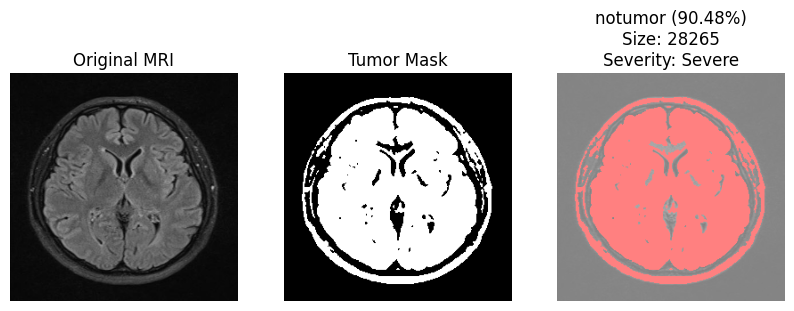

In [15]:
import matplotlib.pyplot as plt

def display_results(img, model, lb):
    """
    img: single MRI image (original, unenhanced)
    model: trained MobileNetV2
    lb: LabelBinarizer for decoding classes
    """
    # --- Tumor Prediction ---
    tumor_type, confidence = predict_tumor(model, img)

    # --- Segmentation ---
    mask, tumor_size = segment_tumor(img)

    # --- Severity ---
    severity = detect_severity(tumor_size)

    # --- Display ---
    plt.figure(figsize=(10,5))

    # Original MRI
    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original MRI")
    plt.axis('off')

    # Tumor Mask
    plt.subplot(1,3,2)
    plt.imshow(mask)
    plt.title("Tumor Mask")
    plt.axis('off')

    # Overlay mask in red on original MRI
    plt.subplot(1,3,3)
    overlay = img.copy()
    overlay[mask[:,:,0]>0] = [1,0,0]  # Red overlay
    plt.imshow(overlay, alpha=0.5)
    plt.title(f"{tumor_type} ({confidence*100:.2f}%)\nSize: {tumor_size}\nSeverity: {severity}")
    plt.axis('off')

    plt.show()

    return tumor_type, confidence, tumor_size, severity

# Example: visualize first test image
tumor_type, confidence, tumor_size, severity = display_results(X_test[0], model_mobilenet, lb)

# `RAM-Safe Gradio UI + PDF Report`

In [18]:
import gradio as gr
import cv2
import numpy as np
import datetime
import os
import pytz
import tensorflow as tf
from fpdf import FPDF
from groq import Groq # Fixed: Using Groq for Llama 3.3
from google.colab import userdata

# --- INITIALIZE GROQ CLIENT ---
# Ensure your Colab Secret is named 'GROQ_API_KEY'
client_groq = Groq(api_key=userdata.get('GROQ_API_KEY'))

def get_ai_suggestions(tumor_type, size, severity, age, gender):
    prompt = f"""
    Act as a Senior Neuroradiologist.
    Analyze these MRI findings for a {age}-year-old {gender} patient:
    - Diagnosis: {tumor_type}
    - Tumor Area: {size} pixels
    - Severity Classification: {severity}

    Task: Write a professional clinical narrative (5-7 sentences) for a medical report.
    Discuss the implications of this {tumor_type} and suggest clinical next steps.
    Do not use bullet points or bold text.
    """
    try:
        completion = client_groq.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.5,
            max_tokens=500
        )
        return completion.choices[0].message.content
    except Exception as e:
        return f"Clinical Analysis currently unavailable. (Error: {str(e)})"

def predict_tumor(model, img):
    # Standardize to 224 (MobileNet standard) and fix TensorShape error
    img_resized = cv2.resize(img, (224, 224))
    img_input = np.expand_dims(img_resized, axis=0)
    # Fix: Convert to a concrete tensor to prevent "as_list()" errors
    input_tensor = tf.convert_to_tensor(img_input, dtype=tf.float32)

    pred = model.predict(input_tensor, verbose=0)[0]
    class_idx = np.argmax(pred)
    tumor_type = lb.classes_[class_idx]
    confidence = pred[class_idx]
    return tumor_type, confidence

In [23]:
def analyze_mri(img, name, age, gender):
    import pytz
    import datetime
    import os

    pk_tz = pytz.timezone('Asia/Karachi')
    now_pk = datetime.datetime.now(pk_tz)
    uid = now_pk.strftime('%Y%m%d_%H%M%S')

    if img.shape[2] == 4:
        img = img[:,:,:3]

    img_display = img.copy()
    h_orig, w_orig = img.shape[:2]
    img_normalized = img.astype(np.float32)/255.0

    # 1. AI Logic
    tumor_type, confidence = predict_tumor(model_mobilenet, img_normalized)
    mask, _ = segment_tumor(img_normalized)

    # Resizing Fix for 442px images
    mask_2d = mask[:, :, 0] if mask.ndim == 3 else mask
    mask_resized = cv2.resize(mask_2d, (w_orig, h_orig), interpolation=cv2.INTER_NEAREST)
    binary_mask = np.where(mask_resized > 0.5, 1, 0).astype(np.uint8)

    actual_count = int(np.sum(binary_mask))
    severity = detect_severity(actual_count)
    ai_report_text = get_ai_suggestions(tumor_type, actual_count, severity, age, gender)

    # 2. Visualizations
    overlay = img_display.copy()
    overlay[binary_mask == 1] = [255, 0, 0]
    mask_visual = (binary_mask * 255)

    # 3. Save unique temporary images
    tmp_orig, tmp_ov, tmp_ms = f"or_{uid}.png", f"ov_{uid}.png", f"ms_{uid}.png"
    cv2.imwrite(tmp_orig, cv2.cvtColor(img_display, cv2.COLOR_RGB2BGR))
    cv2.imwrite(tmp_ov, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
    cv2.imwrite(tmp_ms, mask_visual)

    # 4. PDF Generation
    clean_name = "".join(x for x in name if x.isalnum()) or "Patient"
    pdf_filename = f"/content/{clean_name}_{uid}.pdf"

    pdf = FPDF()
    pdf.add_page()

    # Header
    pdf.set_font("helvetica", "B", 20)
    pdf.set_text_color(44, 62, 80)
    pdf.cell(0, 15, "Brain Tumor Analysis Report", align="C", new_x="LMARGIN", new_y="NEXT")
    pdf.ln(5)

    # Patient Information
    pdf.set_font("helvetica", "B", 12); pdf.set_fill_color(240, 240, 240)
    pdf.cell(0, 10, " Patient Information", fill=True, new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("helvetica", "", 12); pdf.set_text_color(0, 0, 0)
    pdf.cell(0, 10, f"Name: {name} | Age: {age} | Gender: {gender}", new_x="LMARGIN", new_y="NEXT")
    pdf.cell(0, 10, f"Date: {now_pk.strftime('%Y-%m-%d %I:%M %p')}", new_x="LMARGIN", new_y="NEXT")
    pdf.ln(5)

    # --- IMAGE SECTION WITH LABELS ---
    pdf.set_font("helvetica", "B", 12); pdf.cell(0, 10, " Imaging Results", fill=True, new_x="LMARGIN", new_y="NEXT")
    pdf.ln(2)

    # Save current Y to align labels and images
    y_start = pdf.get_y()

    # Set Label Font
    pdf.set_font("helvetica", "B", 10)

    # Place Labels Above Images
    pdf.set_xy(10, y_start); pdf.cell(60, 5, "Original MRI", align="C")
    pdf.set_xy(75, y_start); pdf.cell(60, 5, "Tumor Overlay", align="C")
    pdf.set_xy(140, y_start); pdf.cell(60, 5, "Tumor Mask", align="C")

    # Place Images below the labels
    img_y = y_start + 7
    pdf.image(tmp_orig, 10, img_y, 60)
    pdf.image(tmp_ov, 75, img_y, 60)
    pdf.image(tmp_ms, 140, img_y, 60)

    # 5. Findings & AI (Move Y down to clear the images)
    pdf.set_y(img_y + 65)
    pdf.set_font("helvetica", "B", 12); pdf.cell(0, 10, " Analysis Findings", fill=True, new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("helvetica", "", 12)
    pdf.multi_cell(0, 8, f"Predicted Type: {tumor_type}\nConfidence: {confidence*100:.2f}%\nSize: {actual_count} pixels\nSeverity: {severity}")

    pdf.ln(5); pdf.set_font("helvetica", "B", 12); pdf.set_fill_color(230, 240, 255)
    pdf.cell(0, 10, " Medical Suggestion", fill=True, new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("helvetica", "I", 11); pdf.set_text_color(44, 62, 80)
    pdf.multi_cell(0, 8, ai_report_text)

    pdf.output(pdf_filename)
    return img_display, overlay, mask_visual, tumor_type, confidence*100, actual_count, severity, pdf_filename

In [24]:
# --- Cell 3: Gradio Interface ---

# 1. Clear any existing Gradio instances
try:
    gr.close_all()
except:
    pass

# 2. Define Inputs exactly as requested
inputs = [
    gr.Image(type="numpy", label="Upload MRI Image"),
    gr.Textbox(label="Patient Name"),
    gr.Number(label="Age"),
    gr.Dropdown(["Male", "Female", "Other"], label="Gender")
]

# 3. Define Outputs exactly as requested
outputs = [
    gr.Image(type="numpy", label="Original MRI"),
    gr.Image(type="numpy", label="Overlay with Tumor"),
    gr.Image(type="numpy", label="Tumor Mask"),
    gr.Textbox(label="Predicted Tumor Type"),
    gr.Number(label="Confidence (%)"),
    gr.Number(label="Tumor Size (pixels)"),
    gr.Textbox(label="Severity"),
    gr.File(label="Download PDF Report")
]

# 4. Launch with the "dark" theme
gr.Interface(
    fn=analyze_mri,
    inputs=inputs,
    outputs=outputs,
    title="Brain Tumor Detection & Analysis",
    description="Upload an MRI image to get tumor type, size, severity, and PDF report.",
    theme="dark" # This forces the built-in dark mode
).launch(
    share=True,
    debug=False,
    prevent_thread_lock=False
)

Closing server running on port: 7860


/usr/local/lib/python3.12/dist-packages/gradio/blocks.py:1143: UserWarning: Cannot load dark. Caught Exception: Client error '404 Not Found' for url 'https://huggingface.co/api/spaces/dark' (Request ID: Root=1-69d3f4fa-16b33b04339b7bdc64860569;647c6ae8-4427-4a7e-9c43-fdaf99a83a4a)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/404

Sorry, we can't find the page you are looking for.
  warnings.warn(f"Cannot load {theme}. Caught Exception: {str(e)}")


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bb83b579d76274a626.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# `Saved Model`

In [17]:
# =========================
# ✅ SAVE TRAINED MODEL (Minimal Version)
# =========================

from tensorflow.keras.models import load_model
from google.colab import files

# Save the trained MobileNetV2 model
model_mobilenet.save("mobilenet_model.h5")
print("Model saved successfully as 'mobilenet_model.h5'")

# Download the model to your local computer
files.download("mobilenet_model.h5")

Model saved successfully as 'mobilenet_model.h5'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>